In [8]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [9]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [11]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [12]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [16]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = UNet().to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

        self.train_losses = []
        self.val_losses = []
        self.val_ious = []

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
      best_iou = 0

      for epoch in range(self.config.epochs):
          train_loss = self.train()
          val_loss, val_iou, val_f1 = self.validate()

          self.train_losses.append(train_loss)
          self.val_losses.append(val_loss)
          self.val_ious.append(val_iou)

          if val_iou > best_iou:
              best_iou = val_iou

          print(f"Epoch {epoch+1} / {self.config.epochs}, "
                f"Train Loss: {train_loss:.4f}, "
                f"Val Loss: {val_loss:.4f}, "
                f"Val IoU: {val_iou:.4f}, "
                f"Val F1-score: {val_f1:.4f}")

      self.plot_history()

      return best_iou


    def plot_history(self):
        plt.figure()
        plt.plot(self.train_losses, label="train loss")
        plt.plot(self.val_losses, label="val loss")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(self.val_ious, label="val IoU")
        plt.legend()
        plt.show()

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [17]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Running lr=0.001 bs=16


100%|██████████| 46/46 [00:12<00:00,  3.59it/s]


Epoch 1 / 15, Train Loss: 0.4716, Val Loss: 0.4364, Val IoU: 0.7547, Val F1-score: 0.8524


100%|██████████| 46/46 [00:12<00:00,  3.61it/s]


Epoch 2 / 15, Train Loss: 0.3872, Val Loss: 0.3631, Val IoU: 0.7868, Val F1-score: 0.8750


...

Epoch 13 / 15, Train Loss: 0.1739, Val Loss: 0.1939, Val IoU: 0.8796, Val F1-score: 0.9323


100%|██████████| 46/46 [00:12<00:00,  3.63it/s]


Epoch 14 / 15, Train Loss: 0.1625, Val Loss: 0.1929, Val IoU: 0.8851, Val F1-score: 0.9360


100%|██████████| 46/46 [00:12<00:00,  3.63it/s]

Epoch 15 / 15, Train Loss: 0.1548, Val Loss: 0.2034, Val IoU: 0.8808, Val F1-score: 0.9333


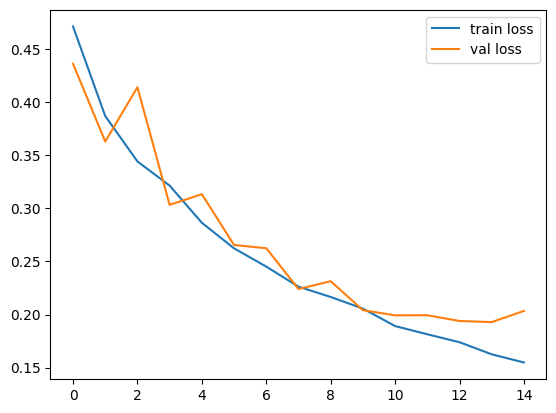

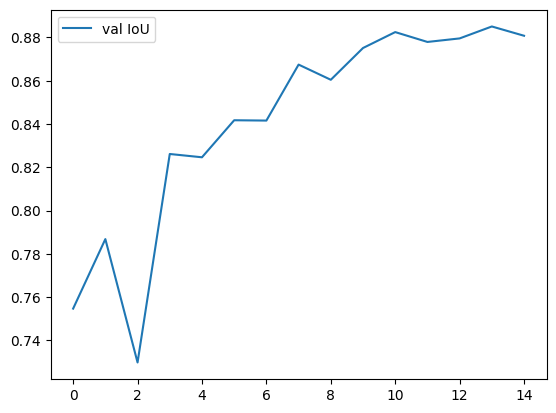

100%|██████████| 46/46 [00:12<00:00,  3.56it/s]


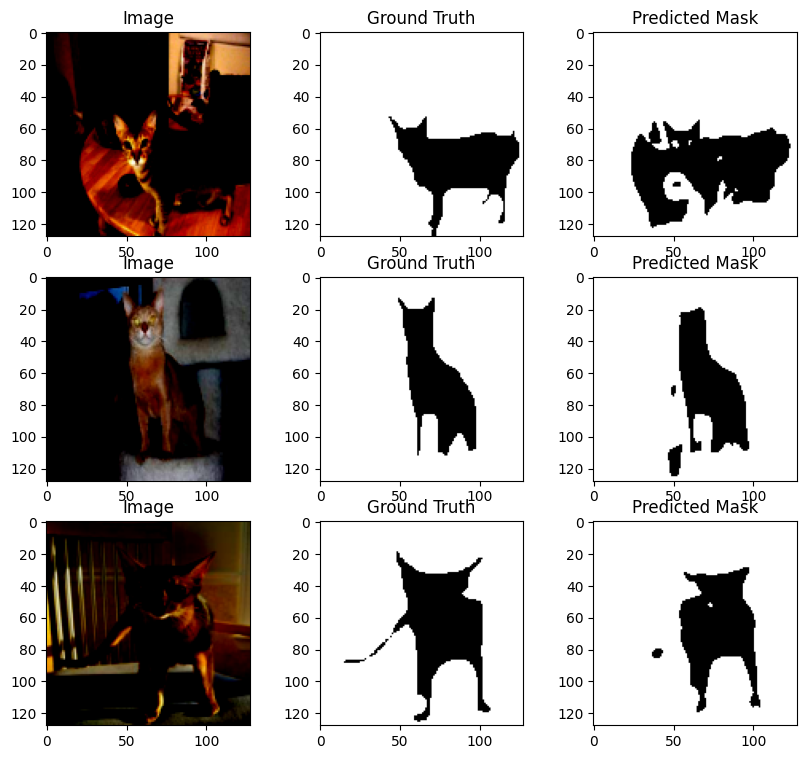

Running lr=0.001 bs=32


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:12<00:00,  1.88it/s]


Epoch 1 / 15, Train Loss: 0.4494, Val Loss: 0.4058, Val IoU: 0.7559, Val F1-score: 0.8559


100%|██████████| 23/23 [00:12<00:00,  1.85it/s]


Epoch 2 / 15, Train Loss: 0.3600, Val Loss: 0.3521, Val IoU: 0.8015, Val F1-score: 0.8838


...

Epoch 13 / 15, Train Loss: 0.1564, Val Loss: 0.2087, Val IoU: 0.8854, Val F1-score: 0.9353


100%|██████████| 23/23 [00:12<00:00,  1.85it/s]


Epoch 14 / 15, Train Loss: 0.1542, Val Loss: 0.1825, Val IoU: 0.8949, Val F1-score: 0.9413


100%|██████████| 23/23 [00:12<00:00,  1.86it/s]

Epoch 15 / 15, Train Loss: 0.1449, Val Loss: 0.2440, Val IoU: 0.8691, Val F1-score: 0.9246


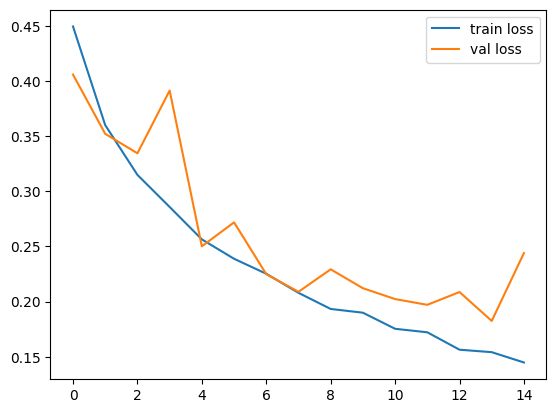

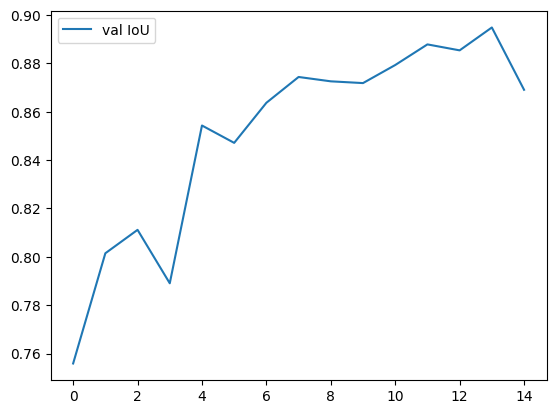

100%|██████████| 23/23 [00:12<00:00,  1.86it/s]


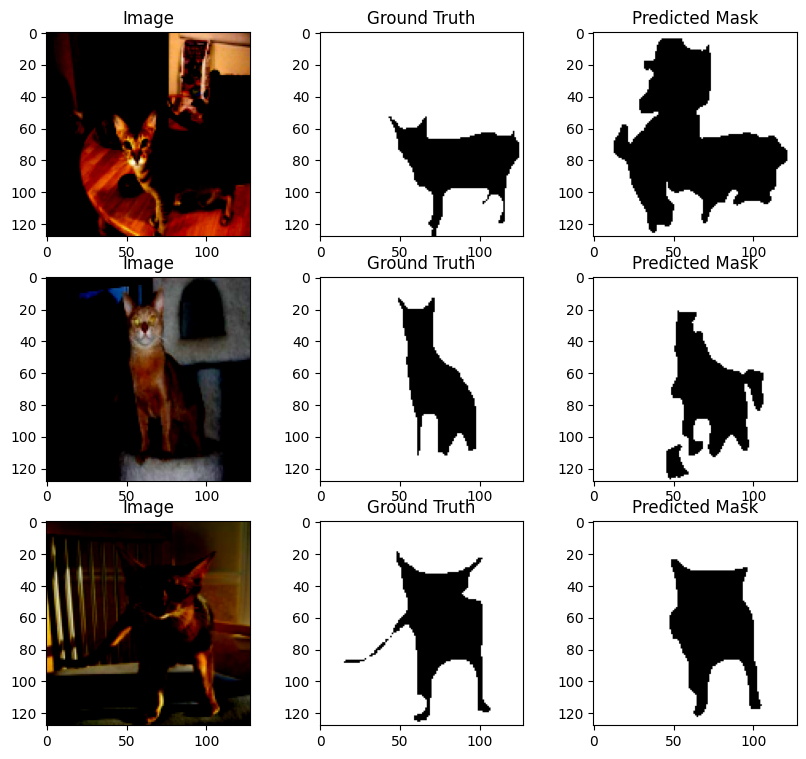

Running lr=0.001 bs=64


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 12/12 [00:12<00:00,  1.07s/it]


Epoch 1 / 15, Train Loss: 0.4687, Val Loss: 0.4435, Val IoU: 0.7271, Val F1-score: 0.8357


100%|██████████| 12/12 [00:13<00:00,  1.09s/it]


Epoch 2 / 15, Train Loss: 0.3665, Val Loss: 0.3881, Val IoU: 0.7853, Val F1-score: 0.8717


...

Epoch 13 / 15, Train Loss: 0.1642, Val Loss: 0.1968, Val IoU: 0.8808, Val F1-score: 0.9323


100%|██████████| 12/12 [00:12<00:00,  1.05s/it]


Epoch 14 / 15, Train Loss: 0.1641, Val Loss: 0.2135, Val IoU: 0.8773, Val F1-score: 0.9305


100%|██████████| 12/12 [00:12<00:00,  1.06s/it]

Epoch 15 / 15, Train Loss: 0.1507, Val Loss: 0.2056, Val IoU: 0.8812, Val F1-score: 0.9329


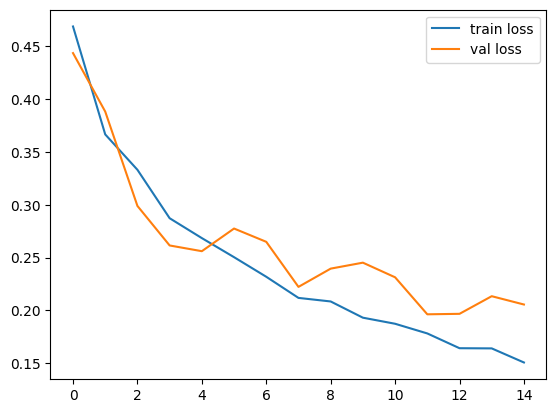

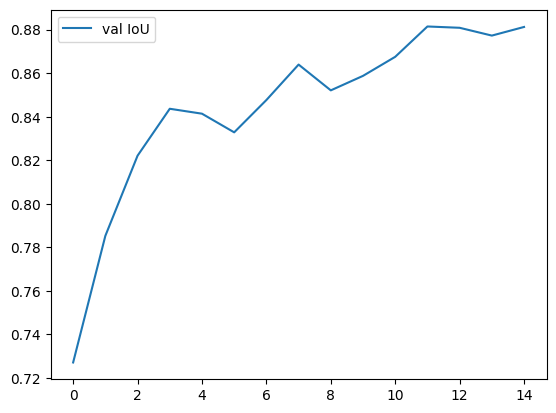

100%|██████████| 12/12 [00:12<00:00,  1.04s/it]


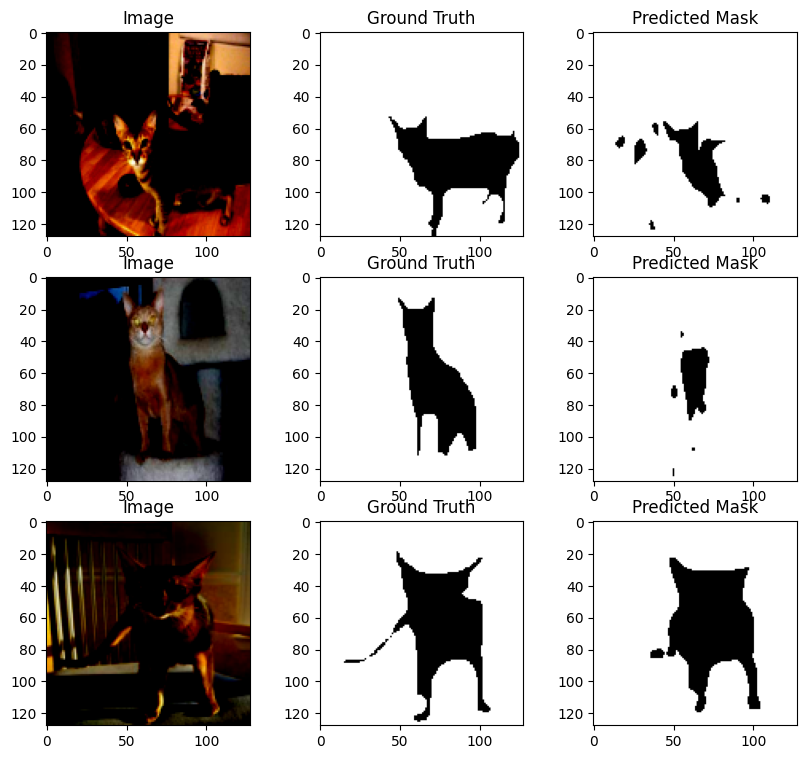

Running lr=0.0001 bs=16


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:13<00:00,  3.52it/s]


Epoch 1 / 15, Train Loss: 0.4469, Val Loss: 0.4026, Val IoU: 0.7697, Val F1-score: 0.8628


100%|██████████| 46/46 [00:13<00:00,  3.47it/s]


Epoch 2 / 15, Train Loss: 0.3170, Val Loss: 0.3090, Val IoU: 0.8310, Val F1-score: 0.9017


...

Epoch 13 / 15, Train Loss: 0.1188, Val Loss: 0.1954, Val IoU: 0.8930, Val F1-score: 0.9399


100%|██████████| 46/46 [00:13<00:00,  3.52it/s]


Epoch 14 / 15, Train Loss: 0.1139, Val Loss: 0.1984, Val IoU: 0.8944, Val F1-score: 0.9399


100%|██████████| 46/46 [00:13<00:00,  3.48it/s]

Epoch 15 / 15, Train Loss: 0.0979, Val Loss: 0.1961, Val IoU: 0.8974, Val F1-score: 0.9422


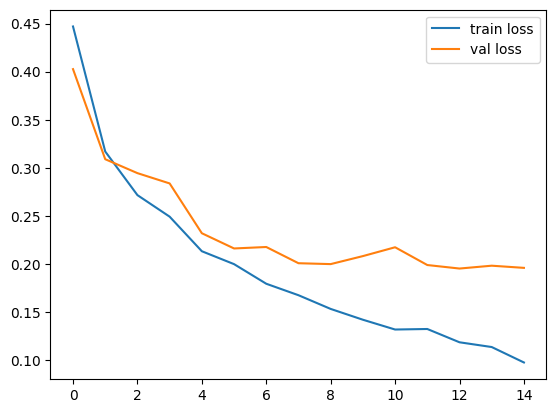

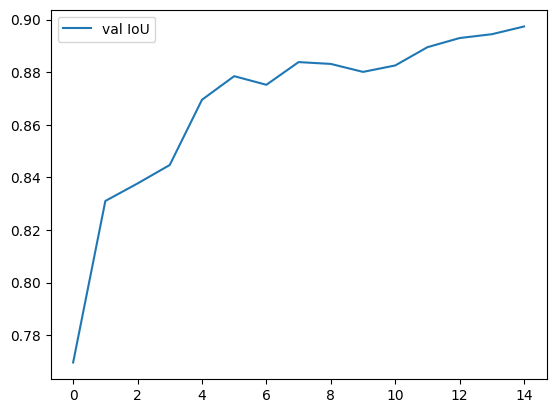

100%|██████████| 46/46 [00:13<00:00,  3.38it/s]


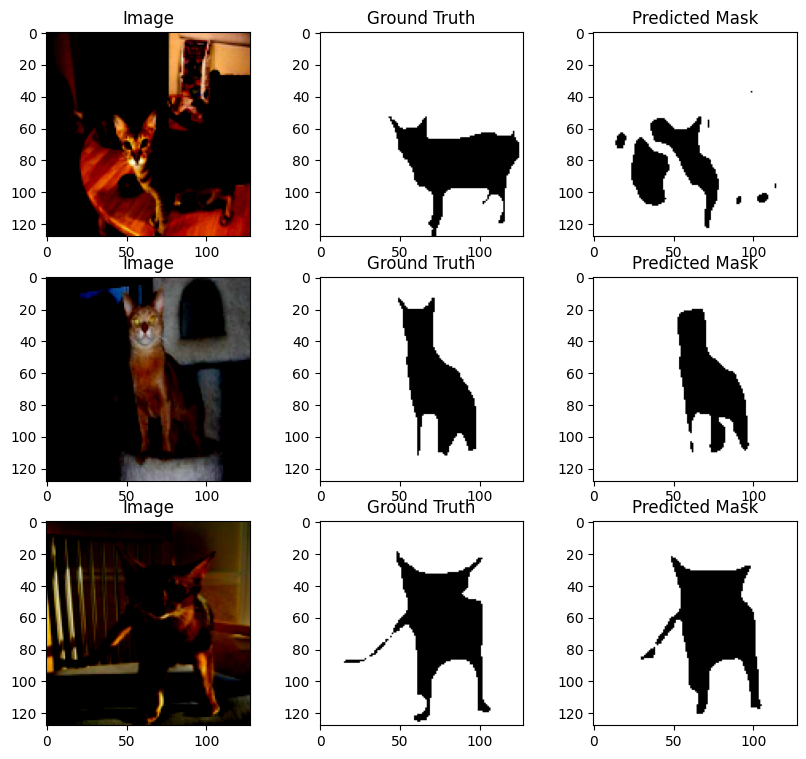

Running lr=0.0001 bs=32


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:12<00:00,  1.85it/s]


Epoch 1 / 15, Train Loss: 0.4864, Val Loss: 0.3727, Val IoU: 0.8143, Val F1-score: 0.8921


100%|██████████| 23/23 [00:12<00:00,  1.83it/s]


Epoch 2 / 15, Train Loss: 0.3439, Val Loss: 0.3329, Val IoU: 0.8152, Val F1-score: 0.8930


...

Epoch 13 / 15, Train Loss: 0.1314, Val Loss: 0.2320, Val IoU: 0.8740, Val F1-score: 0.9287


100%|██████████| 23/23 [00:12<00:00,  1.82it/s]


Epoch 14 / 15, Train Loss: 0.1257, Val Loss: 0.2333, Val IoU: 0.8638, Val F1-score: 0.9225


100%|██████████| 23/23 [00:12<00:00,  1.82it/s]

Epoch 15 / 15, Train Loss: 0.1093, Val Loss: 0.2270, Val IoU: 0.8803, Val F1-score: 0.9325


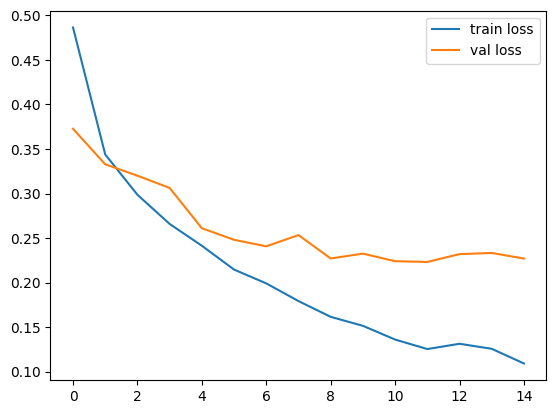

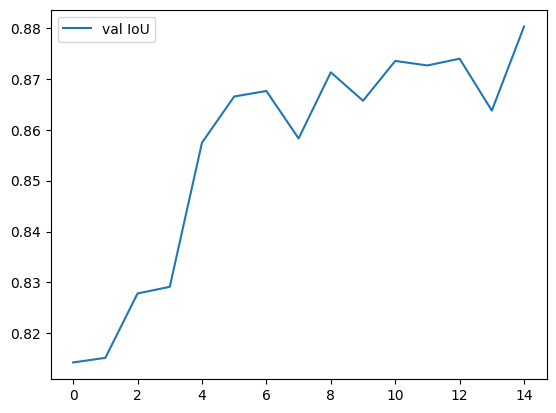

100%|██████████| 23/23 [00:12<00:00,  1.84it/s]


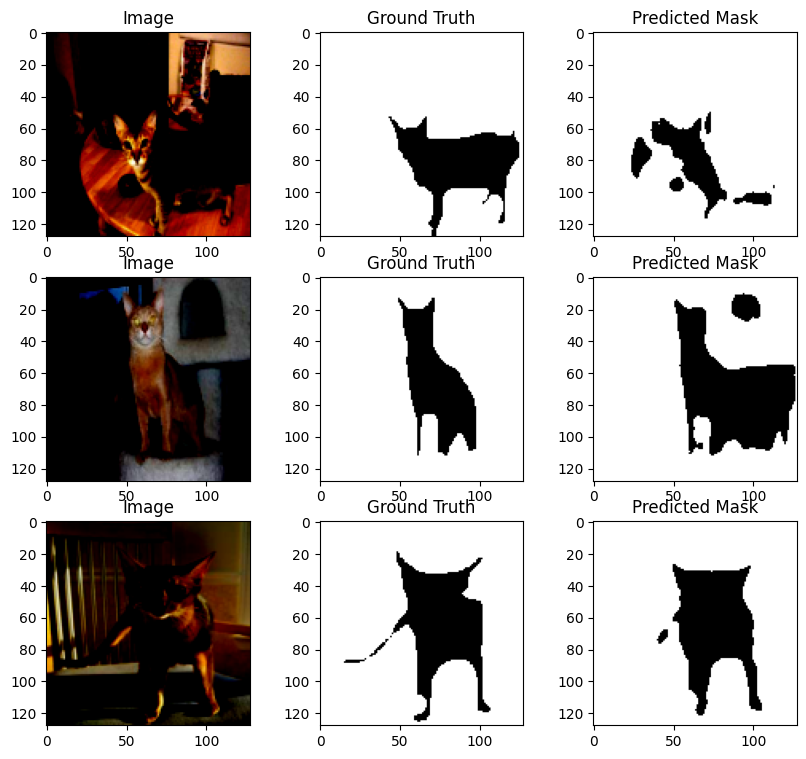

Running lr=0.0001 bs=64


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 12/12 [00:12<00:00,  1.06s/it]


Epoch 1 / 15, Train Loss: 0.4999, Val Loss: 0.4218, Val IoU: 0.7971, Val F1-score: 0.8816


100%|██████████| 12/12 [00:12<00:00,  1.08s/it]


Epoch 2 / 15, Train Loss: 0.3770, Val Loss: 0.3488, Val IoU: 0.8242, Val F1-score: 0.8982


...

Epoch 13 / 15, Train Loss: 0.1434, Val Loss: 0.2518, Val IoU: 0.8685, Val F1-score: 0.9255


100%|██████████| 12/12 [00:12<00:00,  1.08s/it]


Epoch 14 / 15, Train Loss: 0.1299, Val Loss: 0.2242, Val IoU: 0.8808, Val F1-score: 0.9336


100%|██████████| 12/12 [00:13<00:00,  1.09s/it]

Epoch 15 / 15, Train Loss: 0.1212, Val Loss: 0.2406, Val IoU: 0.8730, Val F1-score: 0.9288


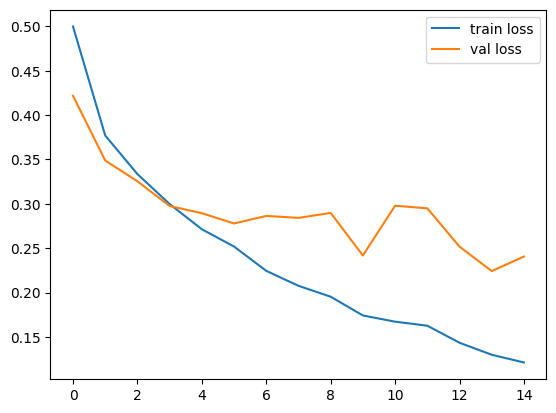

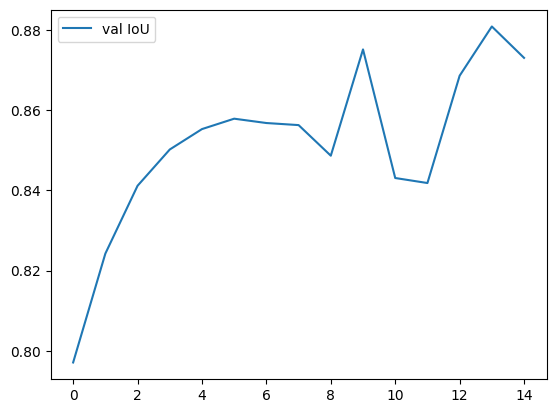

100%|██████████| 12/12 [00:12<00:00,  1.08s/it]


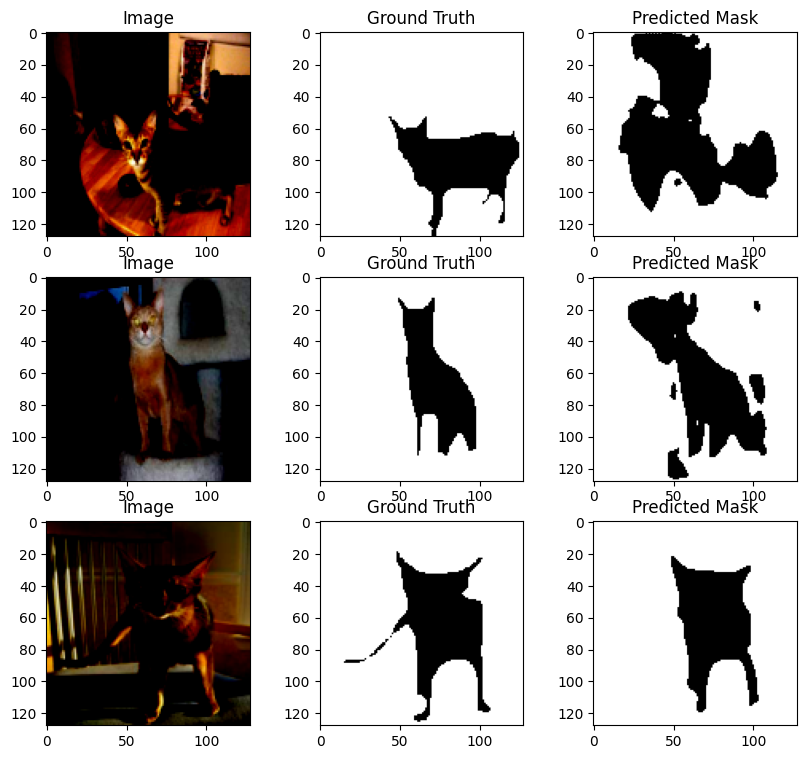

Running lr=1e-05 bs=16


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:13<00:00,  3.42it/s]


Epoch 1 / 15, Train Loss: 0.5799, Val Loss: 0.4376, Val IoU: 0.7956, Val F1-score: 0.8808


100%|██████████| 46/46 [00:13<00:00,  3.41it/s]


Epoch 2 / 15, Train Loss: 0.4130, Val Loss: 0.3867, Val IoU: 0.8171, Val F1-score: 0.8947


...

Epoch 13 / 15, Train Loss: 0.1861, Val Loss: 0.3087, Val IoU: 0.8467, Val F1-score: 0.9129


100%|██████████| 46/46 [00:13<00:00,  3.43it/s]


Epoch 14 / 15, Train Loss: 0.1765, Val Loss: 0.3219, Val IoU: 0.8430, Val F1-score: 0.9109


100%|██████████| 46/46 [00:13<00:00,  3.45it/s]

Epoch 15 / 15, Train Loss: 0.1694, Val Loss: 0.3018, Val IoU: 0.8522, Val F1-score: 0.9165


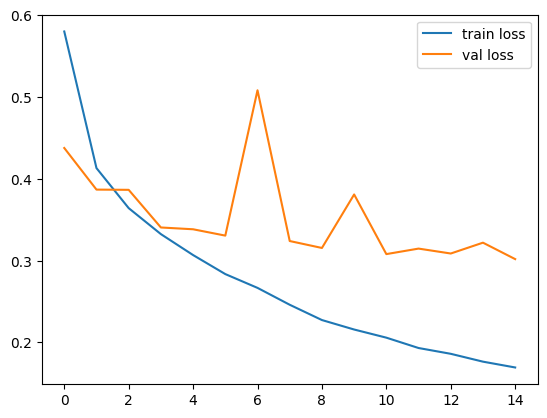

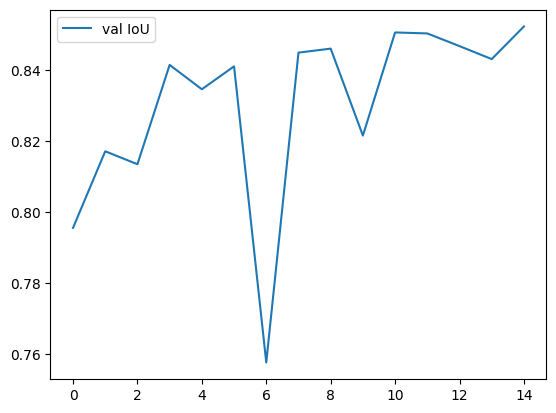

100%|██████████| 46/46 [00:13<00:00,  3.45it/s]


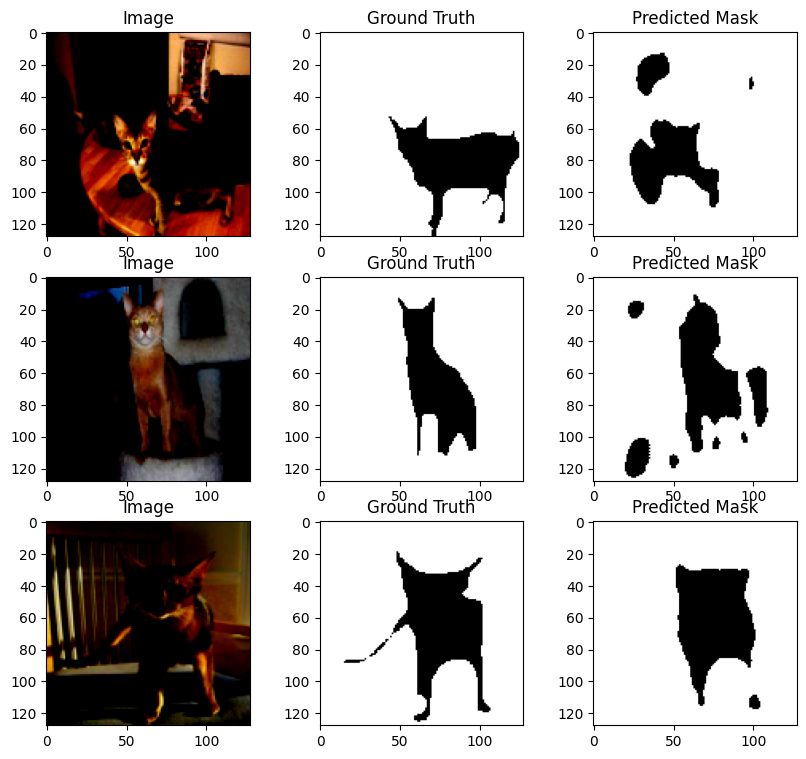

Running lr=1e-05 bs=32


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:12<00:00,  1.86it/s]


Epoch 1 / 15, Train Loss: 0.6378, Val Loss: 0.5147, Val IoU: 0.7542, Val F1-score: 0.8528


100%|██████████| 23/23 [00:12<00:00,  1.87it/s]


Epoch 2 / 15, Train Loss: 0.4755, Val Loss: 0.4214, Val IoU: 0.7972, Val F1-score: 0.8811


...

Epoch 13 / 15, Train Loss: 0.2239, Val Loss: 0.3429, Val IoU: 0.8311, Val F1-score: 0.9029


100%|██████████| 23/23 [00:12<00:00,  1.86it/s]


Epoch 14 / 15, Train Loss: 0.2164, Val Loss: 0.3548, Val IoU: 0.8233, Val F1-score: 0.8985


100%|██████████| 23/23 [00:12<00:00,  1.87it/s]

Epoch 15 / 15, Train Loss: 0.2123, Val Loss: 0.3748, Val IoU: 0.8106, Val F1-score: 0.8899


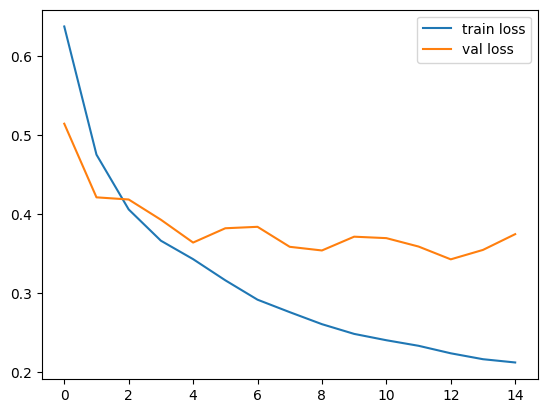

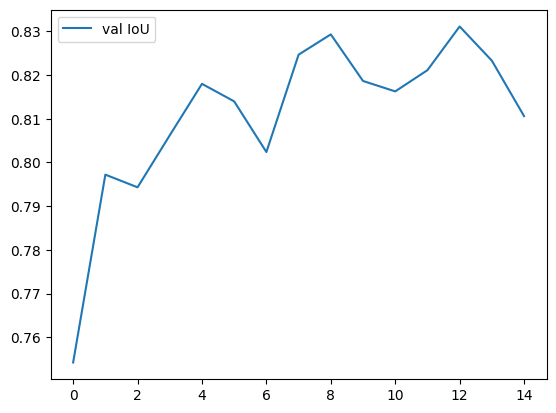

100%|██████████| 23/23 [00:12<00:00,  1.85it/s]


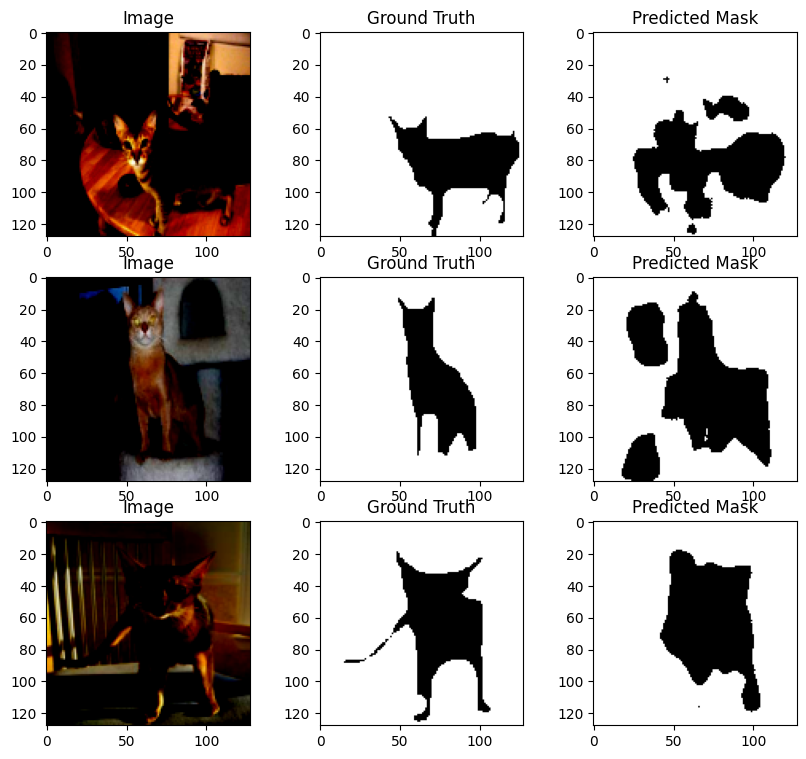

Running lr=1e-05 bs=64


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 12/12 [00:12<00:00,  1.05s/it]


Epoch 1 / 15, Train Loss: 0.6635, Val Loss: 0.6281, Val IoU: 0.5881, Val F1-score: 0.7318


100%|██████████| 12/12 [00:12<00:00,  1.06s/it]


Epoch 2 / 15, Train Loss: 0.5452, Val Loss: 0.4922, Val IoU: 0.7584, Val F1-score: 0.8575


...

Epoch 13 / 15, Train Loss: 0.2535, Val Loss: 0.3594, Val IoU: 0.8340, Val F1-score: 0.9049


100%|██████████| 12/12 [00:12<00:00,  1.03s/it]


Epoch 14 / 15, Train Loss: 0.2458, Val Loss: 0.3632, Val IoU: 0.8313, Val F1-score: 0.9027


100%|██████████| 12/12 [00:12<00:00,  1.05s/it]

Epoch 15 / 15, Train Loss: 0.2412, Val Loss: 0.3865, Val IoU: 0.8121, Val F1-score: 0.8917


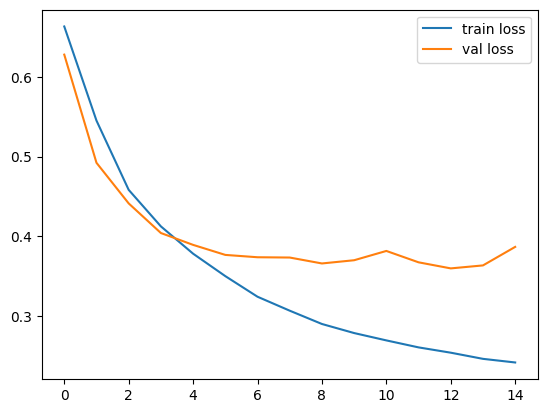

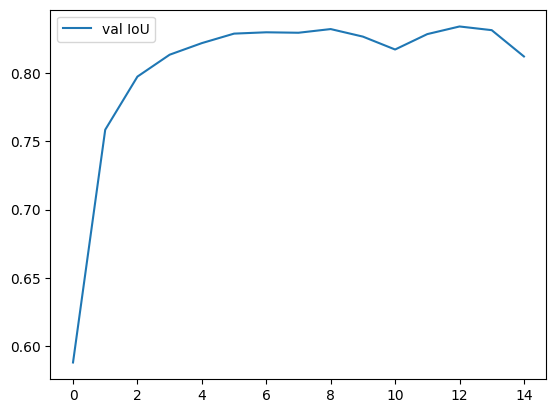

100%|██████████| 12/12 [00:12<00:00,  1.04s/it]


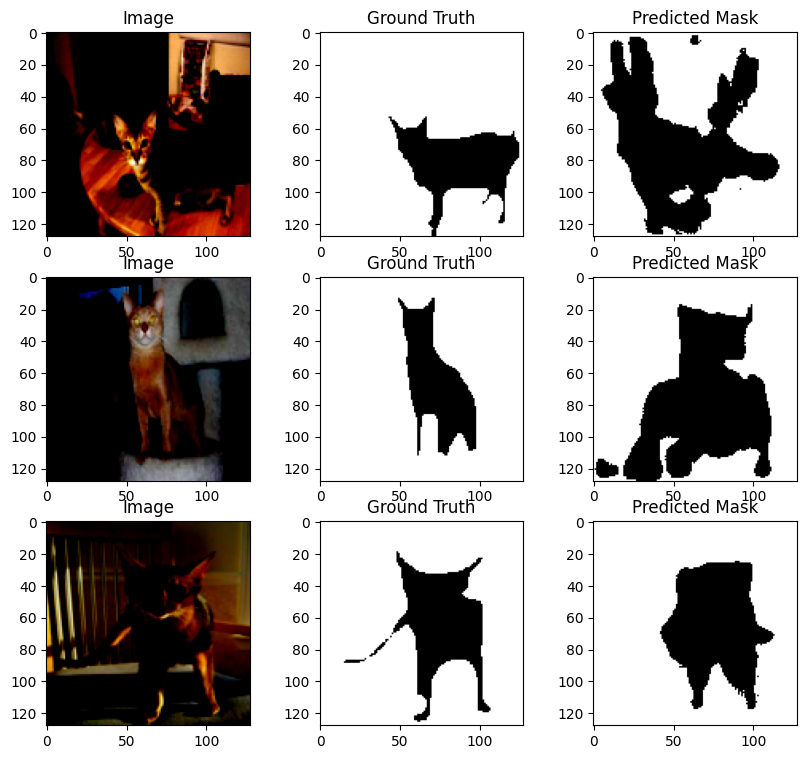

In [18]:
results = {}

lrs = [1e-3, 1e-4, 1e-5]
batches = [16, 32, 64]

for lr in lrs:
    for bs in batches:
        print(f"Running lr={lr} bs={bs}")

        config = Config()
        config.learning_rate = lr
        config.batch_size = bs

        trainer = Trainer(config)
        trainer.run()

        val_loss, val_iou, val_f1 = trainer.validate()

        results[(lr, bs)] = val_iou
        trainer.inference_and_plot_samples(n_samples=3)


Короче я лохушка и забыла записать f1 в историю так что вручную из логов копирую. Офк для лучшего набора гиперпараметров

In [33]:
best_params = None
best_iou = -1

for params, value in results.items():

    # если value = dict
    if isinstance(value, dict):
        iou = value["iou"]
    else:
        iou = value

    if iou > best_iou:
        best_iou = iou
        best_params = params

print("Best hyperparameters:", best_params)
print("Best IoU:", best_iou)

Best hyperparameters: (0.0001, 16)
Best IoU: 0.897359728770666


In [30]:
iou_best = [
0.7697,
0.8310,
0.8377,
0.8447,
0.8695,
0.8785,
0.8752,
0.8838,
0.8831,
0.8801,
0.8825,
0.8895,
0.8930,
0.8944,
0.8974
]
f1_best = [
0.8628,
0.9017,
0.9059,
0.9105,
0.9257,
0.9312,
0.9288,
0.9343,
0.9340,
0.9322,
0.9327,
0.9378,
0.9399,
0.9399,
0.9422
]

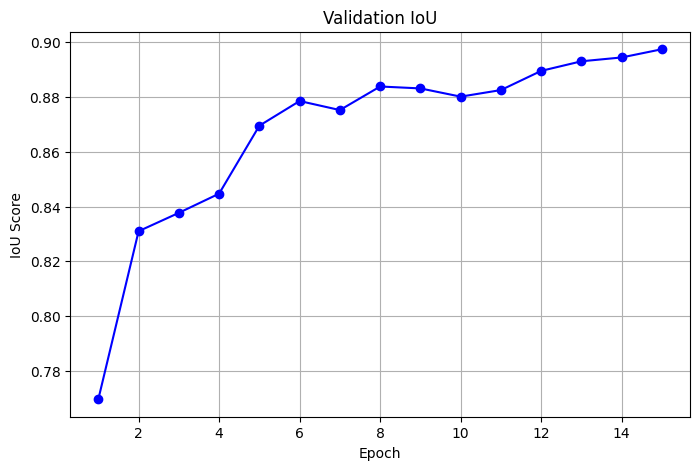

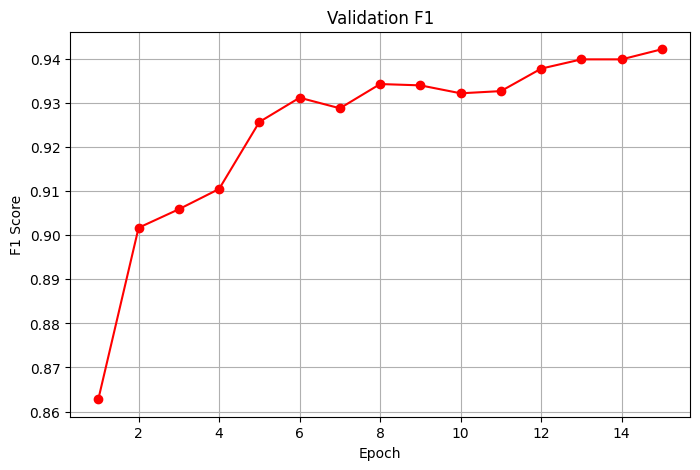

In [34]:
epochs = range(1, 16)

plt.figure(figsize=(8,5))
plt.plot(epochs, iou_best, marker='o', color='blue')

plt.title("Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU Score")
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, f1_best, marker='o', color='red')

plt.title("Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.grid()
plt.show()

### Выводы
Я обучила модель U-Net и провела перебор гиперпараметров learning rate и batch size.
Лучший результат получился при learning rate = 1e-4 и batch size = 16.
По графикам видно, что метрики IoU и F1 постепенно растут и выходят на стабильный уровень, значит модель обучилась правильно.
Таким образом, выбор гиперпараметров сильно влияет на качество сегментации.